# Motion-S v4: Retrieval-Augmented Progressive Generation

**Key improvements over v3:**
- Retrieval-augmented: blend top-K neighbor tokens with model logits
- Progressive residual: base_tokens first, then residuals conditioned on previous layers
- Label smoothing (0.1) for better generalization
- Hybrid length prediction (model + retrieval)
- Multi-candidate selection (3 candidates, pick best likelihood)

---

## 0. Setup

In [1]:
import os, gc, json, math, random, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

T_START = time.time()
TIME_LIMIT = 8.5 * 3600  # 8.5h safety on 9h
def time_left(): return TIME_LIMIT - (time.time() - T_START)
def time_ok(margin=600): return time_left() > margin
print('Setup OK')

Setup OK


In [2]:
def test_cuda():
    if not torch.cuda.is_available(): return False
    try:
        x = torch.randn(2,2,device='cuda')
        _ = F.gelu(x).cpu(); return True
    except: return False

DEVICE = torch.device('cuda' if torch.cuda.is_available() and test_cuda() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Mem: 15.6 GB


In [3]:
import glob
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists(): INPUT_DIR = d; break
if INPUT_DIR is None:
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits: INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None
print(f'Data: {INPUT_DIR}')

OUTPUT_DIR = Path('/kaggle/working')
TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'

TOKEN_COLS = ['base_tokens','residual_1','residual_2',
              'residual_3','residual_4','residual_5']

class CFG:
    num_codebook = 512
    num_layers   = 6
    max_seq_len  = 800
    min_seq_len  = 40
    text_dim     = 512
    # Model
    d_model      = 512
    nhead        = 8
    n_enc_layers = 8       # deeper than v3 (was 6)
    dim_ff       = 2048
    dropout      = 0.1
    # Training
    batch_size   = 48
    lr           = 2e-4     # slightly lower for stability
    weight_decay = 0.01
    epochs       = 25       # more epochs (time guard will stop if needed)
    warmup_ratio = 0.08
    grad_clip    = 1.0
    label_smooth = 0.1     # NEW: label smoothing
    # Inference
    temperature  = 0.8
    top_k        = 48
    ret_weight   = 0.35    # NEW: retrieval prior weight in logit blend
    n_candidates = 3       # NEW: multi-candidate sampling
    ret_k        = 10      # NEW: top-K neighbors for retrieval prior
print('CFG OK')

Data: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
CFG OK


## 1. Data

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '': return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len'] = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_valid = train_df[
    (train_df['seq_len'] >= CFG.min_seq_len) &
    (train_df['seq_len'] <= CFG.max_seq_len)
].copy().reset_index(drop=True)
print(f'Train valid: {len(train_valid)}, Test: {len(test_df)}')

# Pre-parse all train tokens into numpy arrays for fast access
train_tokens = []  # list of [6, sl] numpy arrays
for i in range(len(train_valid)):
    row = train_valid.iloc[i]
    layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
    sl = len(layers[0])
    train_tokens.append(np.array([l[:sl] for l in layers], dtype=np.int64))
print(f'Parsed {len(train_tokens)} token arrays')
print(f'Time: {time.time()-T_START:.0f}s')

Train valid: 12373, Test: 3000
Parsed 12373 token arrays
Time: 147s


## 2. CLIP Encoding (CPU, pooled only)

In [5]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

clip_path = 'openai/clip-vit-base-patch32'
clip_tok = CLIPTokenizer.from_pretrained(clip_path)
clip_mdl = CLIPTextModel.from_pretrained(clip_path).cpu().eval()
for p in clip_mdl.parameters(): p.requires_grad = False
print(f'CLIP loaded: {sum(p.numel() for p in clip_mdl.parameters())/1e6:.0f}M params')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.embeddings.position_ids                           | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded: 63M params


In [6]:
@torch.no_grad()
def clip_encode(texts, bs=128):
    out = []
    for i in range(0,len(texts),bs):
        inp = clip_tok(texts[i:i+bs], padding='max_length',
                       truncation=True, max_length=77, return_tensors='pt')
        o = clip_mdl(**inp)
        out.append(F.normalize(o.pooler_output, dim=-1))
    return torch.cat(out,0)

print('Encoding texts...')
t0 = time.time()

# sentence+gloss for model conditioning
tr_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in train_valid.iterrows()]
te_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in test_df.iterrows()]
tr_emb = clip_encode(tr_texts)  # [N_train, 512]
te_emb = clip_encode(te_texts)  # [N_test, 512]
print(f'  sentence+gloss: {tr_emb.shape}, {te_emb.shape}')

# gloss-only for retrieval
tr_ge = clip_encode(train_valid['gloss'].tolist())
te_ge = clip_encode(test_df['gloss'].tolist())
print(f'  gloss-only: {tr_ge.shape}, {te_ge.shape}')

# sentence-only for retrieval (second signal)
tr_se = clip_encode(train_valid['sentence'].tolist())
te_se = clip_encode(test_df['sentence'].tolist())
print(f'  sentence-only: {tr_se.shape}, {te_se.shape}')

del clip_mdl, clip_tok; gc.collect()
print(f'CLIP done: {time.time()-t0:.0f}s')

Encoding texts...
  sentence+gloss: torch.Size([12373, 512]), torch.Size([3000, 512])
  gloss-only: torch.Size([12373, 512]), torch.Size([3000, 512])
  sentence-only: torch.Size([12373, 512]), torch.Size([3000, 512])
CLIP done: 1686s


## 3. Enhanced Retrieval

Combine gloss + sentence similarity for more robust retrieval.

In [7]:
def topk_ret(te, tr, k=10, ch=500):
    N = te.shape[0]
    idxs = np.zeros((N,k), dtype=np.int64)
    sims = np.zeros((N,k), dtype=np.float32)
    te_np, tr_np = te.numpy(), tr.numpy()
    for i in range(0,N,ch):
        e = min(i+ch, N)
        s = cosine_similarity(te_np[i:e], tr_np)
        for j in range(e-i):
            ix = np.argpartition(s[j],-k)[-k:]
            ix = ix[np.argsort(s[j][ix])[::-1]]
            idxs[i+j]=ix; sims[i+j]=s[j][ix]
    return idxs, sims

# Retrieval using combined similarity: 0.6*gloss + 0.4*sentence
print('Building retrieval index (combined similarity)...')
t0 = time.time()
N_test = len(test_df)
N_train = len(train_valid)
K_RET = CFG.ret_k

# Compute combined similarity in chunks
ret_idx = np.zeros((N_test, K_RET), dtype=np.int64)
ret_sim = np.zeros((N_test, K_RET), dtype=np.float32)
CH = 500
for i in range(0, N_test, CH):
    e = min(i+CH, N_test)
    sg = cosine_similarity(te_ge[i:e].numpy(), tr_ge.numpy())  # gloss sim
    ss = cosine_similarity(te_se[i:e].numpy(), tr_se.numpy())  # sentence sim
    sc = 0.6 * sg + 0.4 * ss  # combined
    for j in range(e-i):
        ix = np.argpartition(sc[j], -K_RET)[-K_RET:]
        ix = ix[np.argsort(sc[j][ix])[::-1]]
        ret_idx[i+j] = ix
        ret_sim[i+j] = sc[j][ix]

print(f'Top-1 sim: mean={ret_sim[:,0].mean():.4f}, min={ret_sim[:,0].min():.4f}')
print(f'Retrieval built: {time.time()-t0:.0f}s')

# Free sentence-only embeddings
del tr_se, te_se; gc.collect()

Building retrieval index (combined similarity)...
Top-1 sim: mean=0.8520, min=0.4641
Retrieval built: 1s


0

## 4. Retrieval Token Prior

For each test sample, build a soft distribution over tokens from top-K neighbors.

In [8]:
def build_retrieval_prior(test_idx, target_len, layer_idx=0):
    """Build a [target_len, 512] soft distribution from top-K retrieved neighbors.
    Uses position-interpolated tokens with similarity weighting."""
    prior = np.zeros((target_len, CFG.num_codebook), dtype=np.float32)
    weights = ret_sim[test_idx]  # [K]
    # Softmax over similarities for weighting
    w = np.exp(weights * 5.0)  # temperature-scaled softmax
    w = w / w.sum()
    
    for k in range(K_RET):
        tr_i = ret_idx[test_idx, k]
        tok_arr = train_tokens[tr_i]  # [6, sl_k]
        src_len = tok_arr.shape[1]
        if src_len == 0: continue
        
        # Map source positions to target positions via linear interpolation
        src_tokens = tok_arr[layer_idx]  # [sl_k]
        for t in range(target_len):
            # Find corresponding source position
            src_pos = t * src_len / target_len
            sp = int(src_pos)
            sp = min(sp, src_len - 1)
            token_val = src_tokens[sp]
            prior[t, token_val] += w[k]
    
    # Normalize rows
    row_sums = prior.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, 1e-8)
    prior = prior / row_sums
    return prior  # [target_len, 512]

# Quick test
p = build_retrieval_prior(0, 100, 0)
print(f'Prior shape: {p.shape}, entropy: {-(p[p>0]*np.log(p[p>0]+1e-10)).sum()/100:.2f}/pos')
print(f'Time: {time.time()-T_START:.0f}s')

Prior shape: (100, 512), entropy: 1.86/pos
Time: 1856s


## 5. Hybrid Length Prediction

Blend learned MLP prediction with retrieval-based length estimate.

In [9]:
class LenPred(nn.Module):
    def __init__(self, d=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,128), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128,1))
    def forward(self, x): return self.net(x).squeeze(-1)

lm = LenPred().to(DEVICE)
lo = torch.optim.AdamW(lm.parameters(), lr=1e-3)
Xl = tr_emb.clone()
yl = torch.log(torch.tensor(train_valid['seq_len'].values, dtype=torch.float32))
ld = DataLoader(torch.utils.data.TensorDataset(Xl, yl), batch_size=512, shuffle=True)

lm.train()
for ep in range(80):  # more epochs for better length pred
    tl, cnt = 0., 0
    for xb, yb in ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(lm(xb), yb)
        lo.zero_grad(); loss.backward(); lo.step()
        tl += loss.item()*len(xb); cnt += len(xb)
    if (ep+1)%40==0: print(f'LenPred ep {ep+1}: MSE={tl/cnt:.4f}')
lm.eval()

@torch.no_grad()
def pred_len_model(emb):
    if emb.dim() == 1: emb = emb.unsqueeze(0)
    p = lm(emb.to(DEVICE))
    return torch.exp(p).round().long().clamp(CFG.min_seq_len, CFG.max_seq_len)

def pred_len_retrieval(test_idx):
    """Weighted average of top-K neighbor lengths."""
    weights = ret_sim[test_idx]  # [K]
    w = np.exp(weights * 5.0); w = w / w.sum()
    lengths = np.array([train_tokens[ret_idx[test_idx, k]].shape[1]
                        for k in range(K_RET)])
    return int(np.round(np.dot(w, lengths)))

def pred_len_hybrid(test_idx, emb, alpha=0.4):
    """Blend model prediction (alpha) with retrieval prediction (1-alpha)."""
    lm_pred = pred_len_model(emb).item()
    rt_pred = pred_len_retrieval(test_idx)
    hybrid = int(np.round(alpha * lm_pred + (1 - alpha) * rt_pred))
    return max(CFG.min_seq_len, min(CFG.max_seq_len, hybrid))

# Test
for i in range(3):
    ml = pred_len_model(te_emb[i]).item()
    rl = pred_len_retrieval(i)
    hl = pred_len_hybrid(i, te_emb[i])
    print(f'  Test {i}: model={ml}, retrieval={rl}, hybrid={hl}')
print(f'Time: {time.time()-T_START:.0f}s')

LenPred ep 40: MSE=0.0830
LenPred ep 80: MSE=0.0702
  Test 0: model=119, retrieval=91, hybrid=102
  Test 1: model=102, retrieval=126, hybrid=116
  Test 2: model=89, retrieval=117, hybrid=106
Time: 1867s


## 6. Progressive NAR Model

Two-stage architecture:
1. **Base generator**: predicts base_tokens from text embedding
2. **Residual refiner**: predicts residual layers conditioned on text + base tokens

Both use self-attention transformers for speed.

In [10]:
class PosEnc(nn.Module):
    def __init__(self, d, mx=1024):
        super().__init__()
        pe = torch.zeros(mx, d)
        pos = torch.arange(mx).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, T): return self.pe[:,:T,:]


class BaseGen(nn.Module):
    """Generates base_tokens from text embedding."""
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(),
            nn.LayerNorm(d), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        self.len_emb = nn.Embedding(cfg.max_seq_len+1, d)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_enc_layers)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))

    def forward(self, txt_emb, sls, tmask=None):
        B = txt_emb.shape[0]
        T = tmask.shape[1] if tmask is not None else sls.max().item()
        pos = self.pos_enc(T).expand(B,-1,-1)
        txt = self.txt_proj(txt_emb).unsqueeze(1)
        lc = self.len_emb(sls.clamp(0,self.cfg.max_seq_len)).unsqueeze(1)
        x = pos + txt + lc
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm)
        return self.head(out)  # [B, T, 512]


class ResidualRefiner(nn.Module):
    """Predicts 5 residual layers conditioned on text + base tokens."""
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.num_codebook, d)  # base token embedding
        self.layer_emb = nn.Embedding(5, d)  # which residual layer
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=6)  # lighter
        self.heads = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))
            for _ in range(5)])  # 5 residual layers

    def forward(self, txt_emb, base_tokens, sls, tmask=None):
        """
        txt_emb: [B, 512]
        base_tokens: [B, T] long
        sls: [B]
        tmask: [B, T]
        Returns: [B, 5, T, 512]
        """
        B, T = base_tokens.shape
        pos = self.pos_enc(T).expand(B,-1,-1)
        txt = self.txt_proj(txt_emb).unsqueeze(1)
        tok = self.tok_emb(base_tokens)  # [B, T, d]
        x = pos + txt + tok  # condition on text + base tokens
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm)
        return torch.stack([h(out) for h in self.heads], 1)  # [B, 5, T, 512]


base_model = BaseGen(CFG).to(DEVICE)
res_model = ResidualRefiner(CFG).to(DEVICE)
bp = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
rp = sum(p.numel() for p in res_model.parameters() if p.requires_grad)
print(f'BaseGen: {bp/1e6:.2f}M, ResidualRefiner: {rp/1e6:.2f}M, Total: {(bp+rp)/1e6:.2f}M')
print(f'Time: {time.time()-T_START:.0f}s')

BaseGen: 26.42M, ResidualRefiner: 21.02M, Total: 47.44M
Time: 1867s


## 7. Training

In [11]:
class MotionDS(Dataset):
    def __init__(self, df, embs, tokens_list):
        self.embs = embs
        self.tokens = tokens_list  # list of [6, sl] numpy
        self.sls = [t.shape[1] for t in tokens_list]
    def __len__(self): return len(self.tokens)
    def __getitem__(self, i):
        return dict(emb=self.embs[i], tok=self.tokens[i], sl=self.sls[i])

def collate(batch):
    B = len(batch); ms = max(b['sl'] for b in batch)
    emb = torch.stack([b['emb'] for b in batch])
    tok = torch.zeros(B,6,ms, dtype=torch.long)
    tmask = torch.zeros(B,ms, dtype=torch.bool)
    sls = torch.tensor([b['sl'] for b in batch], dtype=torch.long)
    for i,b in enumerate(batch):
        sl = b['sl']
        tok[i,:,:sl] = torch.tensor(b['tok'][:,:sl]); tmask[i,:sl] = True
    return dict(emb=emb, tok=tok, tmask=tmask, sls=sls)

ds = MotionDS(train_valid, tr_emb, train_tokens)
dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True,
                collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
print(f'{len(ds)} samples, {len(dl)} batches')

12373 samples, 257 batches


In [12]:
# ---- Stage 1: Train BaseGen ----
print('=== Stage 1: Training BaseGen ===')

opt1 = torch.optim.AdamW(base_model.parameters(), lr=CFG.lr,
                         weight_decay=CFG.weight_decay, betas=(0.9,0.98))
ts1 = CFG.epochs * len(dl)
wu1 = int(ts1 * CFG.warmup_ratio)
def lr_fn1(s):
    if s < wu1: return s/max(1,wu1)
    return 0.5*(1+math.cos(math.pi*(s-wu1)/max(1,ts1-wu1)))
sch1 = torch.optim.lr_scheduler.LambdaLR(opt1, lr_fn1)
scaler1 = GradScaler()
ce_base = nn.CrossEntropyLoss(label_smoothing=CFG.label_smooth)

best1 = float('inf'); hist1 = []; base_model.train(); gs = 0
t_train = time.time()

for ep in range(CFG.epochs):
    if not time_ok(margin=3600):  # need 1h for stage 2 + inference
        print(f'Time guard: stopping base at ep {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    for batch in dl:
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)  # [B,6,T]
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        base_tgt = tok[:, 0, :]  # [B, T] - base tokens only
        
        opt1.zero_grad()
        with autocast():
            logits = base_model(emb, sls, tmask)  # [B, T, 512]
            B, T, V = logits.shape
            lf = F.cross_entropy(logits.reshape(-1,V), base_tgt.reshape(-1),
                                 label_smoothing=CFG.label_smooth, reduction='none')
            mf = tmask.reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum()
        scaler1.scale(loss).backward()
        scaler1.unscale_(opt1)
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), CFG.grad_clip)
        scaler1.step(opt1); scaler1.update(); sch1.step()
        nt = mf.sum().item(); el += loss.item()*nt; et += nt; gs += 1
        if gs % 100 == 0:
            print(f'  s{gs}: loss={el/et:.4f} lr={sch1.get_last_lr()[0]:.2e}')
    al = el/max(1,et); hist1.append(al)
    ep_time = (time.time()-t_train)/(ep+1)
    print(f'Base ep {ep+1}/{CFG.epochs}: {al:.4f} ({ep_time:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best1:
        best1 = al; torch.save(base_model.state_dict(), OUTPUT_DIR/'base_best.pth')
print(f'Base best: {best1:.4f}, time: {time.time()-t_train:.0f}s')

=== Stage 1: Training BaseGen ===
  s100: loss=5.9978 lr=3.89e-05
  s200: loss=5.7548 lr=7.78e-05
Base ep 1/25: 5.6351 (67s/ep, 478min left)
  s300: loss=5.0598 lr=1.17e-04
  s400: loss=4.9931 lr=1.56e-04
  s500: loss=4.9166 lr=1.95e-04
Base ep 2/25: 4.9067 (68s/ep, 477min left)
  s600: loss=4.6294 lr=2.00e-04
  s700: loss=4.5940 lr=2.00e-04
Base ep 3/25: 4.5684 (68s/ep, 475min left)
  s800: loss=4.3674 lr=1.99e-04
  s900: loss=4.3578 lr=1.98e-04
  s1000: loss=4.3478 lr=1.97e-04
Base ep 4/25: 4.3426 (68s/ep, 474min left)
  s1100: loss=4.1792 lr=1.95e-04
  s1200: loss=4.1783 lr=1.93e-04
Base ep 5/25: 4.1782 (68s/ep, 473min left)
  s1300: loss=4.0064 lr=1.91e-04
  s1400: loss=4.0110 lr=1.89e-04
  s1500: loss=4.0284 lr=1.87e-04
Base ep 6/25: 4.0276 (68s/ep, 472min left)
  s1600: loss=3.8401 lr=1.84e-04
  s1700: loss=3.8704 lr=1.81e-04
Base ep 7/25: 3.8744 (68s/ep, 471min left)
  s1800: loss=3.4905 lr=1.78e-04
  s1900: loss=3.7058 lr=1.74e-04
  s2000: loss=3.7169 lr=1.70e-04
Base ep 8/25: 

In [13]:
# ---- Stage 2: Train ResidualRefiner ----
print('=== Stage 2: Training ResidualRefiner ===')

# Load best base model for generating conditioning tokens
base_model.load_state_dict(torch.load(OUTPUT_DIR/'base_best.pth', map_location=DEVICE))
base_model.eval()

# Determine how many epochs we can afford
res_epochs = min(CFG.epochs, 20)
opt2 = torch.optim.AdamW(res_model.parameters(), lr=CFG.lr,
                         weight_decay=CFG.weight_decay, betas=(0.9,0.98))
ts2 = res_epochs * len(dl)
wu2 = int(ts2 * CFG.warmup_ratio)
def lr_fn2(s):
    if s < wu2: return s/max(1,wu2)
    return 0.5*(1+math.cos(math.pi*(s-wu2)/max(1,ts2-wu2)))
sch2 = torch.optim.lr_scheduler.LambdaLR(opt2, lr_fn2)
scaler2 = GradScaler()

best2 = float('inf'); hist2 = []; res_model.train(); gs2 = 0
t_train2 = time.time()

for ep in range(res_epochs):
    if not time_ok(margin=1200):  # need 20min for inference
        print(f'Time guard: stopping residual at ep {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    for batch in dl:
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)  # [B,6,T]
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        base_tok = tok[:, 0, :]  # ground-truth base tokens as conditioning
        res_tgt = tok[:, 1:, :]  # [B, 5, T] residual targets
        
        opt2.zero_grad()
        with autocast():
            logits = res_model(emb, base_tok, sls, tmask)  # [B, 5, T, 512]
            B, NL, T, V = logits.shape
            lf = F.cross_entropy(logits.reshape(-1,V), res_tgt.reshape(-1),
                                 label_smoothing=CFG.label_smooth, reduction='none')
            mf = tmask.unsqueeze(1).expand(-1,NL,-1).reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum()
        scaler2.scale(loss).backward()
        scaler2.unscale_(opt2)
        torch.nn.utils.clip_grad_norm_(res_model.parameters(), CFG.grad_clip)
        scaler2.step(opt2); scaler2.update(); sch2.step()
        nt = mf.sum().item(); el += loss.item()*nt; et += nt; gs2 += 1
        if gs2 % 100 == 0:
            print(f'  s{gs2}: loss={el/et:.4f}')
    al = el/max(1,et); hist2.append(al)
    ep_time = (time.time()-t_train2)/(ep+1)
    print(f'Res ep {ep+1}/{res_epochs}: {al:.4f} ({ep_time:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best2:
        best2 = al; torch.save(res_model.state_dict(), OUTPUT_DIR/'res_best.pth')
print(f'Res best: {best2:.4f}, time: {time.time()-t_train2:.0f}s')

=== Stage 2: Training ResidualRefiner ===
  s100: loss=5.9440
  s200: loss=5.5386
Res ep 1/20: 5.3547 (56s/ep, 449min left)
  s300: loss=4.5338
  s400: loss=4.4110
  s500: loss=4.3027
Res ep 2/20: 4.2882 (56s/ep, 448min left)
  s600: loss=3.9523
  s700: loss=3.9001
Res ep 3/20: 3.8521 (57s/ep, 447min left)
  s800: loss=3.6521
  s900: loss=3.6142
  s1000: loss=3.5761
Res ep 4/20: 3.5655 (57s/ep, 446min left)
  s1100: loss=3.3987
  s1200: loss=3.3845
Res ep 5/20: 3.3640 (57s/ep, 445min left)
  s1300: loss=3.2341
  s1400: loss=3.2299
  s1500: loss=3.2179
Res ep 6/20: 3.2124 (57s/ep, 445min left)
  s1600: loss=3.1274
  s1700: loss=3.1056
Res ep 7/20: 3.0976 (57s/ep, 444min left)
  s1800: loss=3.1184
  s1900: loss=3.0189
  s2000: loss=3.0138
Res ep 8/20: 3.0043 (57s/ep, 443min left)
  s2100: loss=2.9352
  s2200: loss=2.9311
  s2300: loss=2.9296
Res ep 9/20: 2.9294 (57s/ep, 442min left)
  s2400: loss=2.8699
  s2500: loss=2.8688
Res ep 10/20: 2.8661 (57s/ep, 441min left)
  s2600: loss=2.7847


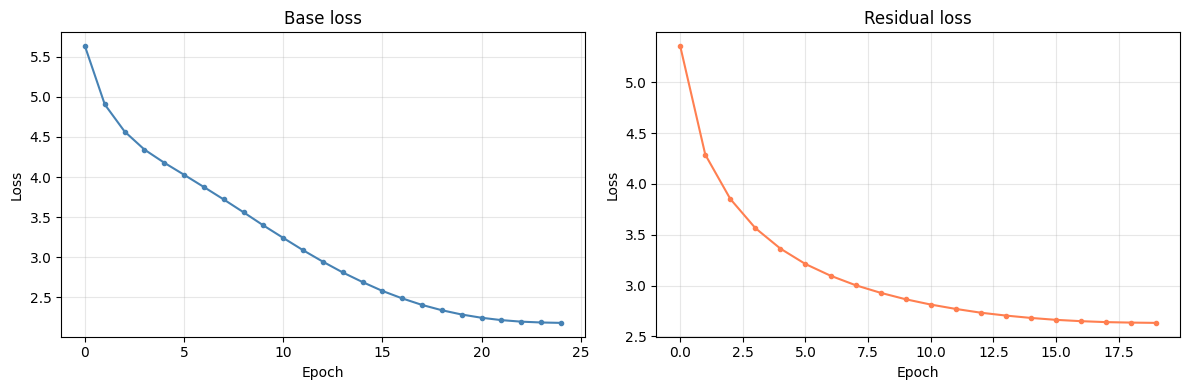

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(hist1,'o-',color='steelblue',ms=3); ax1.set_title('Base loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True,alpha=0.3)
ax2.plot(hist2,'o-',color='coral',ms=3); ax2.set_title('Residual loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Retrieval-Augmented Inference

Blend model logits with retrieval prior for better quality.

In [15]:
# Load best models
base_model.load_state_dict(torch.load(OUTPUT_DIR/'base_best.pth', map_location=DEVICE))
base_model.eval()
res_model.load_state_dict(torch.load(OUTPUT_DIR/'res_best.pth', map_location=DEVICE))
res_model.eval()
print('Models loaded')

Models loaded


In [16]:
@torch.no_grad()
def generate_sample(test_idx, n_candidates=3):
    """Generate one test sample with retrieval augmentation + multi-candidate selection."""
    emb = te_emb[test_idx].unsqueeze(0).to(DEVICE)  # [1, 512]
    sl = pred_len_hybrid(test_idx, te_emb[test_idx])
    sls = torch.tensor([sl], device=DEVICE, dtype=torch.long)
    mask = torch.ones(1, sl, device=DEVICE, dtype=torch.bool)
    
    # Get base logits from model
    base_logits = base_model(emb, sls, mask)  # [1, sl, 512]
    base_logits = base_logits[0]  # [sl, 512]
    
    # Build retrieval prior for base layer
    ret_prior = build_retrieval_prior(test_idx, sl, layer_idx=0)
    ret_prior_t = torch.tensor(ret_prior, device=DEVICE, dtype=torch.float32)
    # Convert prior to log-space and blend
    ret_logits = torch.log(ret_prior_t + 1e-8)
    
    # Blend: (1-w)*model + w*retrieval
    w = CFG.ret_weight
    blended = (1 - w) * (base_logits / CFG.temperature) + w * ret_logits
    
    # Top-k filtering
    if CFG.top_k > 0:
        kv, _ = torch.topk(blended, CFG.top_k, dim=-1)
        blended[blended < kv[:, -1:]] = float('-inf')
    
    # Multi-candidate: sample n_candidates, pick best by log-likelihood
    probs = F.softmax(blended, -1)  # [sl, 512]
    best_base = None
    best_ll = float('-inf')
    
    for _ in range(n_candidates):
        base_sampled = torch.multinomial(probs, 1).squeeze(-1)  # [sl]
        # Score: sum of log-probs of sampled tokens
        ll = torch.log(probs[torch.arange(sl), base_sampled] + 1e-10).sum().item()
        if ll > best_ll:
            best_ll = ll; best_base = base_sampled
    
    # Stage 2: Generate residuals conditioned on base tokens
    base_input = best_base.unsqueeze(0)  # [1, sl]
    res_logits = res_model(emb, base_input, sls, mask)  # [1, 5, sl, 512]
    res_logits = res_logits[0]  # [5, sl, 512]
    
    # Blend residual logits with retrieval prior too
    all_layers = [best_base.cpu().numpy()]  # layer 0 = base
    for li in range(5):
        rl = res_logits[li]  # [sl, 512]
        rp = build_retrieval_prior(test_idx, sl, layer_idx=li+1)
        rp_t = torch.tensor(rp, device=DEVICE, dtype=torch.float32)
        rp_logits = torch.log(rp_t + 1e-8)
        blended_r = (1 - w) * (rl / CFG.temperature) + w * rp_logits
        if CFG.top_k > 0:
            kv, _ = torch.topk(blended_r, CFG.top_k, dim=-1)
            blended_r[blended_r < kv[:, -1:]] = float('-inf')
        rp_probs = F.softmax(blended_r, -1)
        # Multi-candidate for residuals too
        best_res = None; best_rll = float('-inf')
        for _ in range(n_candidates):
            rs = torch.multinomial(rp_probs, 1).squeeze(-1)
            rll = torch.log(rp_probs[torch.arange(sl), rs] + 1e-10).sum().item()
            if rll > best_rll:
                best_rll = rll; best_res = rs
        all_layers.append(best_res.cpu().numpy())
    
    return np.stack(all_layers, 0)  # [6, sl]

print('Generator ready')
print(f'Time: {time.time()-T_START:.0f}s')

Generator ready
Time: 4720s


In [17]:
# For speed: batch the model forward passes, apply retrieval per-sample
@torch.no_grad()
def generate_batch_rag(start_idx, end_idx):
    """Generate a batch with retrieval-augmented blending."""
    B = end_idx - start_idx
    
    # Predict lengths
    seq_lens = []
    for i in range(start_idx, end_idx):
        seq_lens.append(pred_len_hybrid(i, te_emb[i]))
    seq_lens_t = torch.tensor(seq_lens, device=DEVICE, dtype=torch.long)
    max_sl = max(seq_lens)
    
    # Build masks
    mask = torch.arange(max_sl, device=DEVICE).unsqueeze(0) < seq_lens_t.unsqueeze(1)
    embs = te_emb[start_idx:end_idx].to(DEVICE)
    
    # Stage 1: Base model forward (batched)
    base_logits = base_model(embs, seq_lens_t, mask)  # [B, max_sl, 512]
    base_logits = base_logits / CFG.temperature
    
    # Apply retrieval prior + sample per-sample
    all_base = torch.zeros(B, max_sl, device=DEVICE, dtype=torch.long)
    for i in range(B):
        ti = start_idx + i
        sl = seq_lens[i]
        bl = base_logits[i, :sl]  # [sl, 512]
        rp = build_retrieval_prior(ti, sl, 0)
        rp_t = torch.log(torch.tensor(rp, device=DEVICE, dtype=torch.float32) + 1e-8)
        w = CFG.ret_weight
        blended = (1 - w) * bl + w * rp_t
        if CFG.top_k > 0:
            kv, _ = torch.topk(blended, CFG.top_k, dim=-1)
            blended[blended < kv[:, -1:]] = float('-inf')
        probs = F.softmax(blended, -1)
        # Multi-candidate
        best_s = None; best_ll = float('-inf')
        for _ in range(CFG.n_candidates):
            s = torch.multinomial(probs, 1).squeeze(-1)
            ll = torch.log(probs[torch.arange(sl, device=DEVICE), s] + 1e-10).sum().item()
            if ll > best_ll: best_ll = ll; best_s = s
        all_base[i, :sl] = best_s
    
    # Stage 2: Residual model forward (batched)
    res_logits = res_model(embs, all_base, seq_lens_t, mask)  # [B, 5, max_sl, 512]
    res_logits = res_logits / CFG.temperature
    
    # Apply retrieval prior + sample per-sample per-layer
    results = []
    for i in range(B):
        ti = start_idx + i
        sl = seq_lens[i]
        layers = [all_base[i, :sl].cpu().numpy()]
        for li in range(5):
            rl = res_logits[i, li, :sl]  # [sl, 512]
            rp = build_retrieval_prior(ti, sl, li+1)
            rp_t = torch.log(torch.tensor(rp, device=DEVICE, dtype=torch.float32) + 1e-8)
            w = CFG.ret_weight
            blended = (1 - w) * rl + w * rp_t
            if CFG.top_k > 0:
                kv, _ = torch.topk(blended, CFG.top_k, dim=-1)
                blended[blended < kv[:, -1:]] = float('-inf')
            probs = F.softmax(blended, -1)
            best_s = None; best_ll = float('-inf')
            for _ in range(CFG.n_candidates):
                s = torch.multinomial(probs, 1).squeeze(-1)
                ll = torch.log(probs[torch.arange(sl, device=DEVICE), s] + 1e-10).sum().item()
                if ll > best_ll: best_ll = ll; best_s = s
            layers.append(best_s.cpu().numpy())
        results.append(np.stack(layers, 0))  # [6, sl]
    return results

print('Batch RAG generator ready')

Batch RAG generator ready


In [18]:
print(f'Generating {len(test_df)} predictions...')
t0 = time.time()
BATCH_INF = 32  # smaller batch to fit retrieval prior computation
all_preds = []

for i in range(0, len(test_df), BATCH_INF):
    e = min(i + BATCH_INF, len(test_df))
    batch_results = generate_batch_rag(i, e)
    all_preds.extend(batch_results)
    if (i + BATCH_INF) % 200 < BATCH_INF:
        elapsed = time.time() - t0
        rate = (i + BATCH_INF) / elapsed
        eta = (len(test_df) - i - BATCH_INF) / max(rate, 0.1)
        print(f'  {min(e,len(test_df))}/{len(test_df)} '
              f'({elapsed:.0f}s elapsed, ETA ~{eta:.0f}s)')

print(f'Done: {time.time()-t0:.1f}s')
print(f'Sample: shape={all_preds[0].shape}, range=[{all_preds[0].min()},{all_preds[0].max()}]')
print(f'Total time: {(time.time()-T_START)/60:.1f}min')

Generating 3000 predictions...
  224/3000 (5s elapsed, ETA ~65s)
  416/3000 (10s elapsed, ETA ~59s)
  608/3000 (14s elapsed, ETA ~56s)
  800/3000 (18s elapsed, ETA ~49s)
  1024/3000 (22s elapsed, ETA ~43s)
  1216/3000 (26s elapsed, ETA ~38s)
  1408/3000 (30s elapsed, ETA ~34s)
  1600/3000 (33s elapsed, ETA ~29s)
  1824/3000 (38s elapsed, ETA ~24s)
  2016/3000 (42s elapsed, ETA ~20s)
  2208/3000 (45s elapsed, ETA ~16s)
  2400/3000 (49s elapsed, ETA ~12s)
  2624/3000 (54s elapsed, ETA ~8s)
  2816/3000 (57s elapsed, ETA ~4s)
  3000/3000 (61s elapsed, ETA ~-0s)
Done: 60.9s
Sample: shape=(6, 102), range=[2,506]
Total time: 79.7min


## 9. Pure Retrieval Fallback

In [19]:
def ret_submission():
    """Pure retrieval baseline: copy tokens from best match."""
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        # Try top-K until valid length found
        for k in range(K_RET):
            tr_i = ret_idx[i, k]
            tok = train_tokens[tr_i]  # [6, sl]
            sl = tok.shape[1]
            if CFG.min_seq_len <= sl <= CFG.max_seq_len and sl > 0:
                break
        # Fix length if needed
        if sl < CFG.min_seq_len:
            pad = CFG.min_seq_len - sl
            tok = np.concatenate([tok, np.repeat(tok[:, -1:], pad, axis=1)], axis=1)
        elif sl > CFG.max_seq_len:
            tok = tok[:, :CFG.max_seq_len]
        elif sl == 0:
            tok = np.zeros((6, 60), dtype=np.int64)
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS):
            d[cn] = ' '.join(map(str, tok[li].tolist()))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

# Uncomment to use pure retrieval:
# sub = ret_submission()
# sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
# print(f'Retrieval submission: {len(sub)} rows')
print('Retrieval fallback ready (uncomment to use)')

Retrieval fallback ready (uncomment to use)


## 10. Submission

In [20]:
rows = []
for i, (_, r) in enumerate(test_df.iterrows()):
    tid = r['id']
    tok = all_preds[i]  # [6, sl]
    tok = np.clip(tok, 0, 511)  # safety clamp
    d = {'id': tid}
    for li, cn in enumerate(TOKEN_COLS):
        d[cn] = ' '.join(map(str, tok[li].tolist()))
    rows.append(d)
sub = pd.DataFrame(rows)[['id']+TOKEN_COLS]
sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print(f'Saved: {len(sub)} rows')
sub.head(3)

Saved: 3000 rows


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 325 356 75 75 ...,351 212 308 308 308 236 236 424 76 386 124 195...,64 125 125 222 456 153 153 498 498 498 156 177...,474 313 367 445 241 406 367 394 241 295 502 22...
1,6420682,379 326 95 95 95 95 95 95 95 95 312 312 312 95...,339 194 87 87 333 333 333 258 333 333 333 333 ...,48 48 202 356 356 356 356 6 356 356 446 446 44...,351 212 315 503 457 457 401 401 424 236 397 21...,64 413 316 446 71 71 71 456 456 71 498 498 164...,306 241 367 367 186 241 241 241 431 241 241 35...
2,6425789,130 326 326 312 95 224 507 312 95 312 95 95 24...,339 194 87 87 333 333 333 258 258 258 333 333 ...,48 48 48 202 356 6 6 202 202 169 169 58 356 18...,72 212 212 498 503 457 118 401 424 236 497 395...,64 413 413 316 71 109 71 290 498 270 498 498 3...,489 241 241 367 241 305 367 186 367 367 350 43...


## 11. Validation

In [21]:
def validate(df, n=3000):
    errs = []
    if len(df) - n: errs.append(f'Rows: {len(df)} expected {n}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split(); lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511: errs.append(f'R{idx} {c}: {v}'); break
        if len(set(lens)) > 1: errs.append(f'R{idx}: lens {lens}')
        if lens[0] < 40 or lens[0] > 800: errs.append(f'R{idx}: len {lens[0]}')
        if len(errs) > 10: break
    return errs

errs = validate(sub)
if errs:
    for e in errs: print(f'  x {e}')
else:
    print('All checks passed')
sl = sub['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'Len: min={sl.min()} max={sl.max()} mean={sl.mean():.0f}')
print(f'Total time: {(time.time()-T_START)/60:.1f} min')

All checks passed
Len: min=63 max=496 mean=106
Total time: 79.7 min


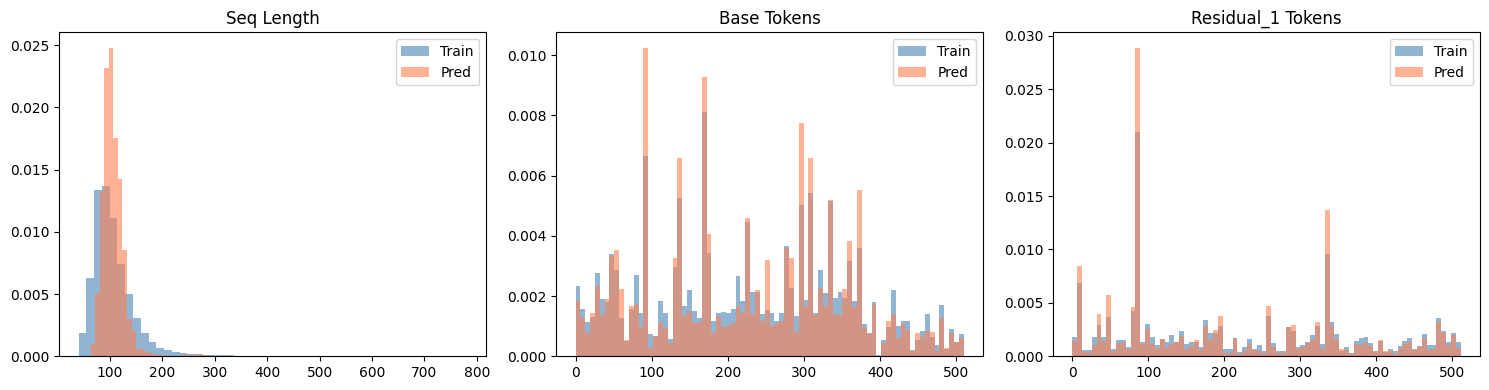

In [22]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

# Length distribution
ax = axes[0]
ax.hist(train_valid['seq_len'],bins=50,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(sl,bins=50,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Seq Length'); ax.legend()

# Base token distribution
ax = axes[1]
tbf=[]; gbf=[]
for _,r in train_valid.head(1000).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:100])
for _,r in sub.head(1000).iterrows(): gbf.extend(list(map(int,str(r['base_tokens']).split()[:100])))
ax.hist(tbf,bins=80,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(gbf,bins=80,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Base Tokens'); ax.legend()

# Residual_1 token distribution
ax = axes[2]
trf=[]; grf=[]
for _,r in train_valid.head(1000).iterrows(): trf.extend(parse_tokens(r['residual_1'])[:100])
for _,r in sub.head(1000).iterrows(): grf.extend(list(map(int,str(r['residual_1']).split()[:100])))
ax.hist(trf,bins=80,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(grf,bins=80,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Residual_1 Tokens'); ax.legend()

plt.tight_layout(); plt.show()

In [23]:
print('='*60)
print('SUMMARY')
print(f'  Total time: {(time.time()-T_START)/60:.1f} min')
print(f'  Time left: {time_left()/60:.0f} min')
print(f'  Base loss: {best1:.4f}')
print(f'  Residual loss: {best2:.4f}')
print(f'  Predictions: {len(all_preds)}')
print(f'  Submission: {OUTPUT_DIR}/submission.csv')
print(f'  Retrieval weight: {CFG.ret_weight}')
print(f'  Candidates per sample: {CFG.n_candidates}')
print('='*60)

SUMMARY
  Total time: 79.7 min
  Time left: 430 min
  Base loss: 2.1768
  Residual loss: 2.6338
  Predictions: 3000
  Submission: /kaggle/working/submission.csv
  Retrieval weight: 0.35
  Candidates per sample: 3
